# Crop Baseline — High-Quality Pill Crops for Classification

- 목적: detection bbox를 classification/OCR 친화적인 crop으로 변환
- 데이터: AI Hub single 경구약제 (`detection_single.csv`)
- 핵심 원칙: 원본 이미지 crop, 정사각형 margin crop, reflect padding
- bbox 소스: GT bbox 또는 YOLO `best.pt` 예측 bbox 선택 가능
- 기본 권장: 실제 파이프라인과 맞추기 위해 YOLO prediction bbox 사용
- 안정성: YOLO 추론은 chunk 단위로 수행하고 Drive에 진행상황을 저장해 resume 가능


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install ultralytics opencv-python-headless -q

from google.colab import auth
auth.authenticate_user()

import gc
import math
import os
import shutil
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from ultralytics import YOLO
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 200)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Manifest 로드 및 스키마 확인

- baseline과 동일하게 detection manifest를 기준으로 사용
- 이후 classification label은 `item_seq`를 사용


In [5]:
MANIFEST_PATH = "gs://pilliot-raw-data-2026/04_manifests/detection_single.csv"
df = pd.read_csv(MANIFEST_PATH)

print(f"rows: {len(df):,}")
print("columns:", df.columns.tolist())
display(df.head(2))

print("\n--- zip별 annotation 수 ---")
display(df.groupby(['split_type', 'label_zip_name']).size().reset_index(name='count'))


rows: 2,611,983
columns: ['dataset_type', 'split_type', 'label_zip_name', 'image_file', 'item_seq', 'dl_name', 'width', 'height', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'area']


,dataset_type,split_type,label_zip_name,image_file,item_seq,dl_name,width,height,category_id,bbox_x,bbox_y,bbox_w,bbox_h,area
0,single,train,TL_21_단일.zip,K-000027_0_2_0_0_75_000_200.png,195900043,아네모정 90mg/PTP,976,1280,1,294.0,475.0,285.0,279.0,79515.0
1,single,train,TL_21_단일.zip,K-000027_0_2_0_0_75_020_200.png,195900043,아네모정 90mg/PTP,976,1280,1,303.0,461.0,275.0,276.0,75900.0



--- zip별 annotation 수 ---


,split_type,label_zip_name,count
0,train,TL_10_단일.zip,64800
1,train,TL_11_단일.zip,64800
2,train,TL_12_단일.zip,64584
3,train,TL_13_단일.zip,64800
4,train,TL_14_단일.zip,64800
...,...,...,...
86,validation,VL_5_단일.zip,15120
87,validation,VL_6_단일.zip,15228
88,validation,VL_7_단일.zip,13284
89,validation,VL_8_단일.zip,15444


## 2. Subset 선택

- 우선 YOLO baseline과 같은 subset으로 맞춤
- crop 품질 검증 후 zip 범위를 넓혀도 됨


In [6]:
TRAIN_LABEL_ZIPS = ['TL_38_단일.zip']
VAL_LABEL_ZIPS = ['VL_1_단일.zip']

def label_to_image_zip(label_zip):
    return label_zip.replace('TL_', 'TS_').replace('VL_', 'VS_')

train_df = df[df['label_zip_name'].isin(TRAIN_LABEL_ZIPS)].copy()
val_df = df[df['label_zip_name'].isin(VAL_LABEL_ZIPS)].copy()

train_df['split'] = 'train'
val_df['split'] = 'validation'

print(f"train rows: {len(train_df):,}")
print(f"val rows:   {len(val_df):,}")
display(train_df[['split', 'label_zip_name', 'image_file', 'item_seq', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']].head(3))


train rows: 12,852
val rows:   14,472


,split,label_zip_name,image_file,item_seq,bbox_x,bbox_y,bbox_w,bbox_h
801466,train,TL_38_단일.zip,K-012685_0_0_0_0_75_000_200.png,200300198,385.0,522.0,193.0,190.0
801467,train,TL_38_단일.zip,K-012685_0_0_0_0_75_020_200.png,200300198,387.0,525.0,191.0,188.0
801468,train,TL_38_단일.zip,K-012685_0_0_0_0_75_040_200.png,200300198,391.0,527.0,189.0,188.0


## 3. 원본 이미지 다운로드

- 반드시 원본 이미지에서 crop
- YOLO 입력용 640 letterbox 이미지에서 crop하지 않음


In [7]:
!df -h /content

shutil.rmtree('/content/raw_images', ignore_errors=True)
shutil.rmtree('/content/crops', ignore_errors=True)


Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /


In [8]:
GCS_BASE = "gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/single"

def download_and_extract(label_zips, split, subset_df):
    dst = Path(f"/content/raw_images/{split}")
    dst.mkdir(parents=True, exist_ok=True)

    for label_zip in label_zips:
        image_zip = label_to_image_zip(label_zip)
        gcs_src = f"{GCS_BASE}/{split}/images/{image_zip}"
        selected = set(subset_df.loc[subset_df['label_zip_name'] == label_zip, 'image_file'].tolist())

        if not selected:
            print(f"skip {label_zip}: no selected images")
            continue

        print(f"Downloading {image_zip} ...")
        ret = os.system(f'gcloud storage cp "{gcs_src}" /content/tmp_images.zip')
        if ret != 0 or not Path('/content/tmp_images.zip').exists():
            print(f"  ERROR: download failed for {image_zip}")
            continue

        extracted = 0
        with zipfile.ZipFile('/content/tmp_images.zip') as zf:
            for member in zf.namelist():
                fname = Path(member).name
                if fname in selected:
                    (dst / fname).write_bytes(zf.read(member))
                    extracted += 1

        os.remove('/content/tmp_images.zip')
        used_gb = shutil.disk_usage('/content').used / 1e9
        print(f"  extracted: {extracted:,} images  disk used: {used_gb:.1f} GB")

download_and_extract(TRAIN_LABEL_ZIPS, 'train', train_df)
download_and_extract(VAL_LABEL_ZIPS, 'validation', val_df)


  extracted: 12,852 images  disk used: 41.5 GB
  extracted: 14,472 images  disk used: 62.1 GB


## 4. BBox 소스 선택

- 학습은 다시 하지 않고, 이미 만든 `best.pt`로 raw image에 추론만 수행
- 한 번에 전체 이미지를 넘기지 않고 chunk 단위로 예측
- 각 chunk 결과를 Drive 캐시에 저장해서 세션이 죽어도 resume 가능
- 기본값은 실제 파이프라인에 맞춘 `BBOX_SOURCE='yolo'`


In [9]:
BBOX_SOURCE = 'yolo'  # 'ground_truth' or 'yolo'
YOLO_WEIGHT_CANDIDATES = [
    '/content/drive/MyDrive/Conference/Pillot/runs/yolo11n_single_baseline/weights/best.pt',
    '/content/runs/yolo11n_single_baseline/weights/best.pt',
]
YOLO_IMGSZ = 640
YOLO_CONF = 0.25
YOLO_IOU = 0.70
YOLO_CHUNK_SIZE = 64
YOLO_BATCH_SIZE = 8
YOLO_PROGRESS_DIR = Path('/content/drive/MyDrive/Conference/Pillot/cache/yolo_bbox')
YOLO_PROGRESS_DIR.mkdir(parents=True, exist_ok=True)

def resolve_yolo_weights_path(candidates=YOLO_WEIGHT_CANDIDATES):
    for candidate in candidates:
        if Path(candidate).exists():
            print(f'Using YOLO weights: {candidate}')
            return str(candidate)
    raise FileNotFoundError(f'YOLO weights not found. Checked: {candidates}')

YOLO_WEIGHTS_PATH = resolve_yolo_weights_path()

def build_gt_crop_df(subset_df):
    gt_df = subset_df.reset_index(drop=True).copy()
    gt_df['source_bbox'] = 'ground_truth'
    gt_df['pred_conf'] = np.nan
    gt_df['has_detection'] = True
    return gt_df

def load_progress_df(progress_path):
    if progress_path.exists():
        progress_df = pd.read_csv(progress_path)
        if 'has_detection' not in progress_df.columns:
            progress_df['has_detection'] = True
        return progress_df
    return pd.DataFrame()

def build_yolo_crop_df(
    subset_df,
    split,
    weights_path=YOLO_WEIGHTS_PATH,
    imgsz=YOLO_IMGSZ,
    conf=YOLO_CONF,
    iou=YOLO_IOU,
    chunk_size=YOLO_CHUNK_SIZE,
    batch_size=YOLO_BATCH_SIZE,
    progress_dir=YOLO_PROGRESS_DIR,
):
    src_dir = Path(f'/content/raw_images/{split}')
    base_df = subset_df[['split', 'image_file', 'item_seq', 'label_zip_name']].drop_duplicates('image_file').reset_index(drop=True)
    progress_path = progress_dir / f'{split}_yolo_pred.csv'
    progress_df = load_progress_df(progress_path)

    processed_images = set(progress_df['image_file']) if len(progress_df) else set()
    remaining_df = base_df[~base_df['image_file'].isin(processed_images)].reset_index(drop=True)

    print(f'[{split}] total images: {len(base_df):,}')
    print(f'[{split}] cached images: {len(processed_images):,}')
    print(f'[{split}] remaining images: {len(remaining_df):,}')

    if len(remaining_df):
        if not Path(weights_path).exists():
            raise FileNotFoundError(f'YOLO weights not found: {weights_path}')

        image_lookup = {row['image_file']: row for _, row in base_df.iterrows()}
        model = YOLO(weights_path)
        predict_device = 0 if torch.cuda.is_available() else 'cpu'

        for start in tqdm(range(0, len(remaining_df), chunk_size), desc=f'{split} yolo predict'):
            chunk_df = remaining_df.iloc[start:start + chunk_size].copy()
            chunk_paths = [str(src_dir / image_file) for image_file in chunk_df['image_file']]

            chunk_results = model.predict(
                chunk_paths,
                imgsz=imgsz,
                conf=conf,
                iou=iou,
                batch=batch_size,
                device=predict_device,
                save=False,
                verbose=False,
            )

            chunk_records = []
            for image_path, result in zip(chunk_paths, chunk_results):
                image_file = Path(image_path).name
                base_row = image_lookup[image_file]
                boxes = result.boxes

                if boxes is None or len(boxes) == 0:
                    chunk_records.append({
                        'split': split,
                        'label_zip_name': base_row['label_zip_name'],
                        'image_file': image_file,
                        'item_seq': base_row['item_seq'],
                        'bbox_x': np.nan,
                        'bbox_y': np.nan,
                        'bbox_w': np.nan,
                        'bbox_h': np.nan,
                        'source_bbox': 'yolo_none',
                        'pred_conf': np.nan,
                        'has_detection': False,
                    })
                    continue

                confs = boxes.conf.detach().cpu().numpy()
                best_idx = int(np.argmax(confs))
                x1, y1, x2, y2 = boxes.xyxy[best_idx].detach().cpu().numpy().tolist()

                chunk_records.append({
                    'split': split,
                    'label_zip_name': base_row['label_zip_name'],
                    'image_file': image_file,
                    'item_seq': base_row['item_seq'],
                    'bbox_x': float(x1),
                    'bbox_y': float(y1),
                    'bbox_w': float(max(0.0, x2 - x1)),
                    'bbox_h': float(max(0.0, y2 - y1)),
                    'source_bbox': 'yolo_pred',
                    'pred_conf': float(confs[best_idx]),
                    'has_detection': True,
                })

            chunk_progress_df = pd.DataFrame(chunk_records)
            progress_df = pd.concat([progress_df, chunk_progress_df], ignore_index=True)
            progress_df = progress_df.drop_duplicates(subset=['image_file'], keep='last')
            progress_df.to_csv(progress_path, index=False)

            del chunk_results
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    else:
        print(f'[{split}] resume cache hit: no remaining images to predict')

    progress_df = load_progress_df(progress_path)
    detected_df = progress_df[progress_df['has_detection'].fillna(False)].copy().reset_index(drop=True)
    no_det = int((~progress_df['has_detection'].fillna(False)).sum()) if len(progress_df) else 0

    print(f'[{split}] YOLO detections kept: {len(detected_df):,}  no detection: {no_det:,}')
    print(f'[{split}] progress cache: {progress_path}')
    if len(detected_df):
        display(detected_df.head(3))
    return detected_df


Using YOLO weights: /content/drive/MyDrive/Conference/Pillot/runs/yolo11n_single_baseline/weights/best.pt


## 5. Crop 정책

- bbox 타이트 crop 대신 정사각형 margin crop
- 경계 밖으로 나가면 reflect padding
- crop 단계에서는 raw square crop만 저장
- 최종 classifier 입력 resize는 dataloader/transform 단계에서 수행
- `BBOX_SOURCE='yolo'`이면 detector 오차가 반영된 실제 파이프라인 crop


In [10]:
CROP_MARGIN_RATIO = 0.20
PADDING_MODE = 'reflect'
SAVE_EXT = '.png'

PAD_MODE_MAP = {
    'reflect': cv2.BORDER_REFLECT_101,
    'edge': cv2.BORDER_REPLICATE,
    'constant': cv2.BORDER_CONSTANT,
}

assert PADDING_MODE in PAD_MODE_MAP

def read_rgb(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(image_path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def bbox_to_xyxy(row):
    x1 = float(row['bbox_x'])
    y1 = float(row['bbox_y'])
    x2 = x1 + float(row['bbox_w'])
    y2 = y1 + float(row['bbox_h'])
    return x1, y1, x2, y2

def build_square_crop_box(row, margin_ratio=CROP_MARGIN_RATIO):
    x1, y1, x2, y2 = bbox_to_xyxy(row)
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    side = max(x2 - x1, y2 - y1) * (1.0 + margin_ratio)
    return cx - side / 2.0, cy - side / 2.0, cx + side / 2.0, cy + side / 2.0

def crop_square_from_original(image, row, padding_mode=PADDING_MODE):
    img_h, img_w = image.shape[:2]
    crop_x1, crop_y1, crop_x2, crop_y2 = build_square_crop_box(row)

    pad_left = max(0, int(math.ceil(-crop_x1)))
    pad_top = max(0, int(math.ceil(-crop_y1)))
    pad_right = max(0, int(math.ceil(crop_x2 - img_w)))
    pad_bottom = max(0, int(math.ceil(crop_y2 - img_h)))

    padded = cv2.copyMakeBorder(
        image,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        borderType=PAD_MODE_MAP[padding_mode],
        value=[0, 0, 0],
    )

    crop_x1 += pad_left
    crop_x2 += pad_left
    crop_y1 += pad_top
    crop_y2 += pad_top

    x1i = int(np.floor(crop_x1))
    y1i = int(np.floor(crop_y1))
    x2i = int(np.ceil(crop_x2))
    y2i = int(np.ceil(crop_y2))

    crop = padded[y1i:y2i, x1i:x2i]
    if crop.size == 0:
        raise ValueError('Empty crop generated')

    raw_h, raw_w = crop.shape[:2]
    crop_side = float(max(crop_x2 - crop_x1, crop_y2 - crop_y1))
    pad_fraction = (pad_left + pad_right + pad_top + pad_bottom) / max(crop_side * 4.0, 1.0)

    meta = {
        'bbox_x1': round(float(row['bbox_x']), 4),
        'bbox_y1': round(float(row['bbox_y']), 4),
        'bbox_x2': round(float(row['bbox_x']) + float(row['bbox_w']), 4),
        'bbox_y2': round(float(row['bbox_y']) + float(row['bbox_h']), 4),
        'crop_side_px': round(crop_side, 4),
        'raw_h': int(raw_h),
        'raw_w': int(raw_w),
        'pad_left': pad_left,
        'pad_right': pad_right,
        'pad_top': pad_top,
        'pad_bottom': pad_bottom,
        'pad_fraction': round(pad_fraction, 6),
    }
    return crop, meta


## 6. Crop 생성 및 manifest 저장

- YOLO bbox는 chunk 단위로 예측한 뒤 Drive 캐시를 사용
- crop은 `/content/crops/{split}/{item_seq}/...png`에 저장
- crop metadata csv는 `/content`에 저장
- `BBOX_SOURCE='ground_truth'`로 바꾸면 상한선 실험도 가능


In [11]:
RUN_TRAIN = True
RUN_VAL = False

# Save crops to Drive so we can resume after a Colab disconnect.
CROP_OUTPUT_ROOT = Path('/content/drive/MyDrive/Conference/Pillot/cache/crops')
CROP_PROGRESS_DIR = Path('/content/drive/MyDrive/Conference/Pillot/cache/crop_progress')
CROP_PROGRESS_DIR.mkdir(parents=True, exist_ok=True)
CROP_SAVE_EVERY = 200

def resolve_crop_source_df(subset_df, split):
    if BBOX_SOURCE == 'ground_truth':
        return build_gt_crop_df(subset_df)
    if BBOX_SOURCE == 'yolo':
        return build_yolo_crop_df(subset_df, split)
    raise ValueError(f'Unsupported BBOX_SOURCE: {BBOX_SOURCE}')

def load_crop_progress_df(progress_path):
    if progress_path.exists():
        return pd.read_csv(progress_path)
    return pd.DataFrame()

def flush_crop_progress(progress_path, existing_df, pending_records):
    if not pending_records:
        return existing_df
    pending_df = pd.DataFrame(pending_records)
    combined_df = pd.concat([existing_df, pending_df], ignore_index=True)
    combined_df.to_csv(progress_path, index=False)
    return combined_df

def build_crop_dataset(
    crop_df,
    split,
    output_root=CROP_OUTPUT_ROOT,
    progress_dir=CROP_PROGRESS_DIR,
    save_every=CROP_SAVE_EVERY,
):
    src_dir = Path(f"/content/raw_images/{split}")
    out_root = output_root / split
    out_root.mkdir(parents=True, exist_ok=True)

    valid_df = crop_df.dropna(subset=['bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']).copy()
    valid_df = valid_df[(valid_df['bbox_w'] > 0) & (valid_df['bbox_h'] > 0)].reset_index(drop=True)

    progress_path = progress_dir / f"{split}_crop_manifest.csv"
    crop_manifest = load_crop_progress_df(progress_path)
    processed_crop_files = set(crop_manifest['crop_file']) if len(crop_manifest) else set()
    initial_cached = len(processed_crop_files)

    print(f"{split}: source bbox rows {len(crop_df):,}")
    print(f"{split}: valid bbox rows {len(valid_df):,}")
    print(f"{split}: cached crops {initial_cached:,}")
    print(f"{split}: remaining crops {max(len(valid_df) - initial_cached, 0):,}")

    pending_records = []
    missing_images = 0
    created_dirs = set()

    for ann_idx, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc=f"{split} crops"):
        crop_name = f"{Path(row['image_file']).stem}_{row['source_bbox']}_ann{ann_idx:06d}{SAVE_EXT}"
        if crop_name in processed_crop_files:
            continue

        image_path = src_dir / row['image_file']
        if not image_path.exists():
            missing_images += 1
            continue

        image = read_rgb(image_path)
        crop, meta = crop_square_from_original(image, row)

        class_dir = out_root / str(row['item_seq'])
        class_dir_key = str(class_dir)
        if class_dir_key not in created_dirs:
            class_dir.mkdir(parents=True, exist_ok=True)
            created_dirs.add(class_dir_key)

        crop_path = class_dir / crop_name
        if not crop_path.exists():
            Image.fromarray(crop).save(crop_path)

        pending_records.append({
            'split': split,
            'item_seq': row['item_seq'],
            'image_file': row['image_file'],
            'crop_file': crop_name,
            'crop_path': str(crop_path.relative_to('/content')),
            'label_zip_name': row['label_zip_name'],
            'source_bbox': row['source_bbox'],
            'pred_conf': row.get('pred_conf', np.nan),
            **meta,
        })
        processed_crop_files.add(crop_name)

        if len(pending_records) >= save_every:
            crop_manifest = flush_crop_progress(progress_path, crop_manifest, pending_records)
            pending_records = []

    crop_manifest = flush_crop_progress(progress_path, crop_manifest, pending_records)

    manifest_path = Path(f"/content/crops_{split}_manifest.csv")
    crop_manifest.to_csv(manifest_path, index=False)

    print(f"{split}: saved total crops {len(crop_manifest):,}")
    print(f"{split}: saved this run {max(len(crop_manifest) - initial_cached, 0):,}")
    print(f"{split}: missing source images {missing_images:,}")
    print(f"{split}: progress manifest {progress_path}")
    if len(crop_manifest):
        display(crop_manifest.head(3))
    return crop_manifest

train_crop_manifest = pd.DataFrame()
val_crop_manifest = pd.DataFrame()

if RUN_TRAIN:
    train_crop_df = resolve_crop_source_df(train_df, 'train')
    train_crop_manifest = build_crop_dataset(train_crop_df, 'train')
else:
    print('RUN_TRAIN=False -> train split skipped')

if RUN_VAL:
    val_crop_df = resolve_crop_source_df(val_df, 'validation')
    val_crop_manifest = build_crop_dataset(val_crop_df, 'validation')
else:
    print('RUN_VAL=False -> validation split skipped')

if not train_crop_manifest.empty:
    print("\n--- train class counts (top 10) ---")
    display(train_crop_manifest['item_seq'].value_counts().head(10))

summary_dict = {}
if not train_crop_manifest.empty:
    summary_dict['train'] = train_crop_manifest['pad_fraction'].describe()
if not val_crop_manifest.empty:
    summary_dict['validation'] = val_crop_manifest['pad_fraction'].describe()

if summary_dict:
    print("\n--- padding summary ---")
    display(pd.DataFrame(summary_dict))


[train] total images: 12,852
[train] cached images: 6,656
[train] remaining images: 6,196


train yolo predict:   0%|          | 0/97 [00:00<?, ?it/s]

[train] YOLO detections kept: 12,852  no detection: 0
[train] progress cache: /content/drive/MyDrive/Conference/Pillot/cache/yolo_bbox/train_yolo_pred.csv


,split,label_zip_name,image_file,item_seq,bbox_x,bbox_y,bbox_w,bbox_h,source_bbox,pred_conf,has_detection
0,train,TL_38_단일.zip,K-012685_0_0_0_0_75_000_200.png,200300198,381.008057,523.626526,194.231873,185.608154,yolo_pred,0.886278,True
1,train,TL_38_단일.zip,K-012685_0_0_0_0_75_020_200.png,200300198,382.695251,524.924194,192.715332,186.330322,yolo_pred,0.889318,True
2,train,TL_38_단일.zip,K-012685_0_0_0_0_75_040_200.png,200300198,386.817444,526.500244,190.668152,185.371826,yolo_pred,0.891138,True


train: source bbox rows 12,852
train: valid bbox rows 12,852
train: cached crops 0
train: remaining crops 12,852


...

,split,item_seq,image_file,crop_file,crop_path,label_zip_name,source_bbox,pred_conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2,crop_side_px,raw_h,raw_w,pad_left,pad_right,pad_top,pad_bottom,pad_fraction
0,train,200300198,K-012685_0_0_0_0_75_000_200.png,K-012685_0_0_0_0_75_000_200_yolo_pred_ann00000...,drive/MyDrive/Conference/Pillot/cache/crops/tr...,TL_38_단일.zip,yolo_pred,0.886278,381.0081,523.6265,575.2399,709.2347,233.0782,234,234,0,0,0,0,0.0
1,train,200300198,K-012685_0_0_0_0_75_020_200.png,K-012685_0_0_0_0_75_020_200_yolo_pred_ann00000...,drive/MyDrive/Conference/Pillot/cache/crops/tr...,TL_38_단일.zip,yolo_pred,0.889318,382.6953,524.9242,575.4106,711.2545,231.2584,232,232,0,0,0,0,0.0
2,train,200300198,K-012685_0_0_0_0_75_040_200.png,K-012685_0_0_0_0_75_040_200_yolo_pred_ann00000...,drive/MyDrive/Conference/Pillot/cache/crops/tr...,TL_38_단일.zip,yolo_pred,0.891138,386.8174,526.5002,577.4856,711.8721,228.8018,230,230,0,0,0,0,0.0


RUN_VAL=False -> validation split skipped

--- train class counts (top 10) ---


,count
item_seq,
200300269,324
200300251,324
200300431,324
200300412,324
200300312,324
200300463,324
200300418,324
200300393,324
200300408,324



--- padding summary ---


,train
count,12852.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


## 7. 샘플 QC

- crop이 지나치게 타이트한지
- reflect padding이 얼마나 자주 발생하는지
- item_seq별로 시각 품질이 유지되는지 확인


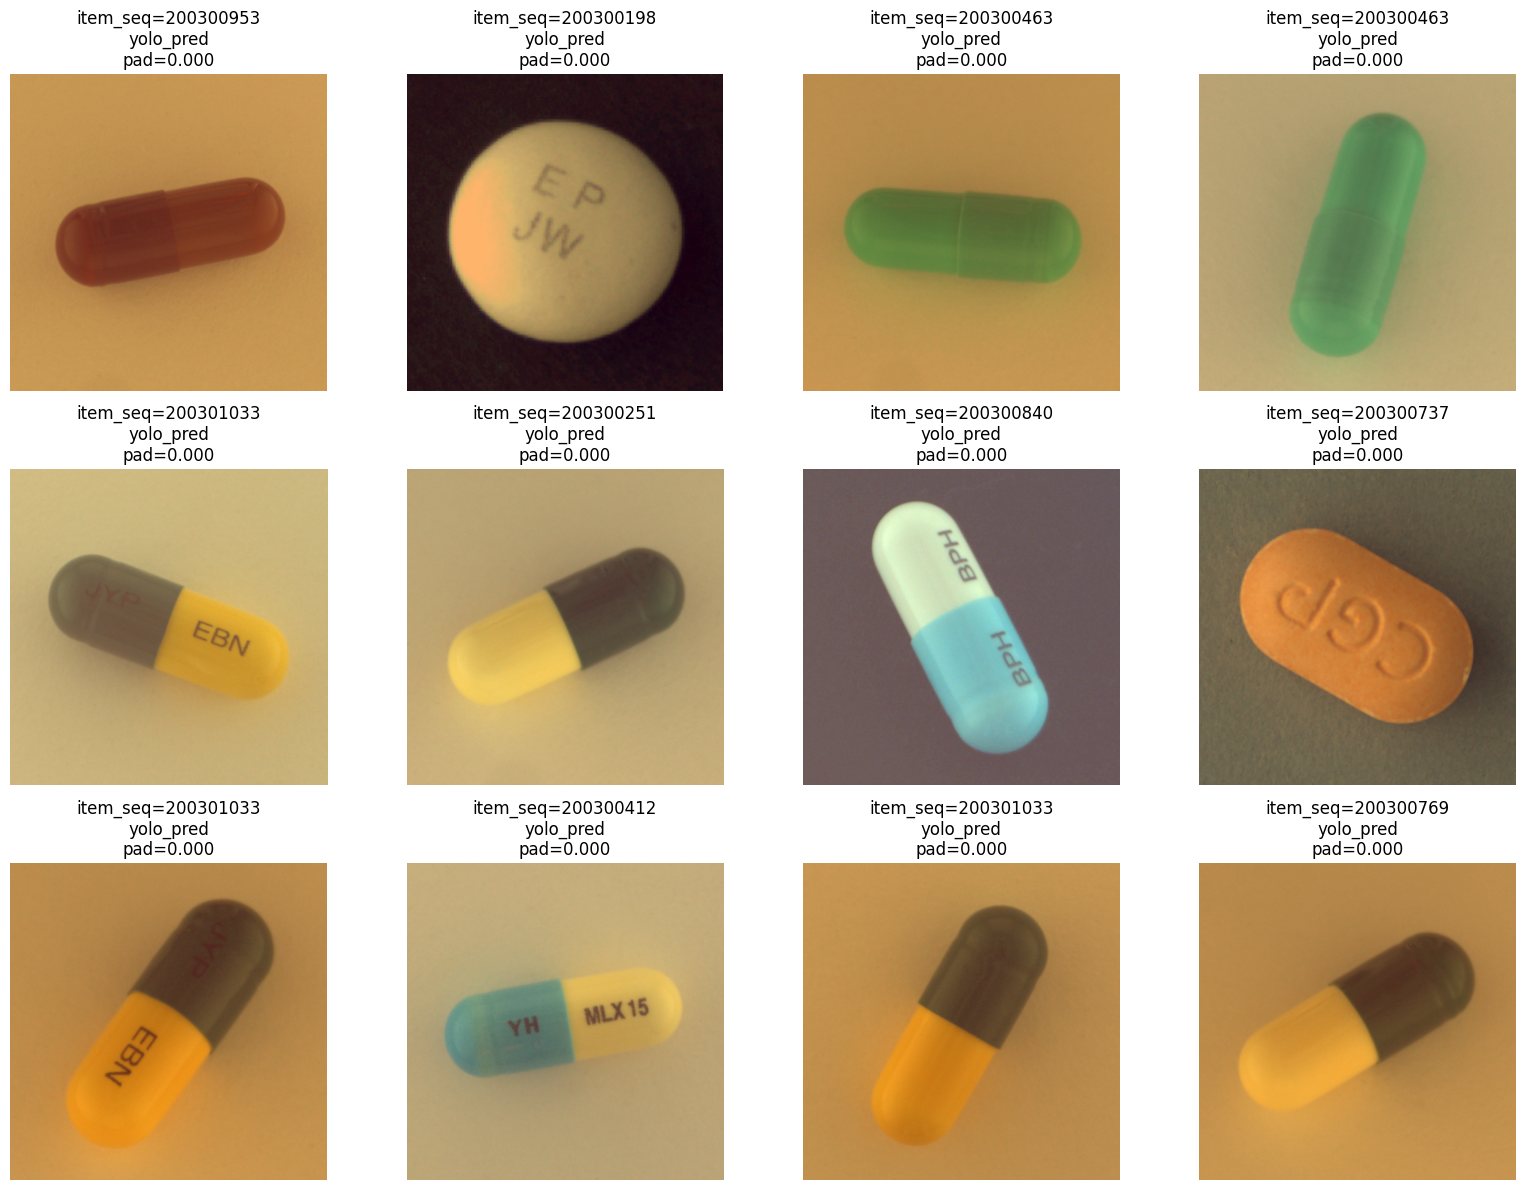

In [12]:
def show_samples(crop_manifest, n=12, seed=42):
    if crop_manifest.empty:
        print('No crops to display')
        return

    sample = crop_manifest.sample(n=min(n, len(crop_manifest)), random_state=seed).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(sample) / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, rec in sample.iterrows():
        ax = plt.subplot(rows, cols, i + 1)
        img = Image.open(Path('/content') / rec['crop_path'])
        ax.imshow(img)
        ax.set_title(f"item_seq={rec['item_seq']}\n{rec['source_bbox']}\npad={rec['pad_fraction']:.3f}")
        ax.axis('off')
    plt.tight_layout()

show_samples(train_crop_manifest, n=12)
